In [15]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

#ML model 1 AND 2 + model 1 for 3 periods


In [16]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


bank_files = {
    "JPM_JPMorgan_Chase.csv": "JPMorgan Chase",
    "BAC_Bank_of_America.csv": "Bank of America",
    "C_Citigroup.csv": "Citigroup",
    "GS_Goldman_Sachs.csv": "Goldman Sachs",
    "WFC_Wells_Fargo.csv": "Wells Fargo"
}

START_DATE = pd.Timestamp("2015-01-01")
END_DATE   = pd.Timestamp("2025-01-01")

rate_df = pd.read_csv("FEDFUNDS.csv")
rate_df["Date"] = pd.to_datetime(rate_df["observation_date"])
rate_df["YearMonth"] = rate_df["Date"].dt.to_period("M")
rate_df = rate_df[["YearMonth", "FEDFUNDS"]]


def process_bank(file_name, bank_label):

    df = pd.read_csv(file_name)
    df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_localize(None)

    df = df[(df["Date"] >= START_DATE) & (df["Date"] < END_DATE)].copy()


    df["YearMonth"] = df["Date"].dt.to_period("M")


    merged = df.merge(rate_df, on="YearMonth", how="left")
    merged = merged.dropna(subset=["Close", "FEDFUNDS"])


    X = merged[["FEDFUNDS"]]
    y = merged["Close"]

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)


    result = {
        "Bank":        bank_label,
        "Intercept":   round(model.intercept_, 4),
        "Slope":       round(model.coef_[0], 4),
        "R2":          round(r2_score(y, y_pred), 4),
        "MAE":         round(mean_absolute_error(y, y_pred), 4),
        "RMSE":        round(np.sqrt(mean_squared_error(y, y_pred)), 4),
        "Correlation": round(merged["FEDFUNDS"].corr(merged["Close"]), 4),
        "N":           len(merged)
    }

    return merged, model, result


all_data        = {}
all_models      = {}
summary_results = []

for file_name, bank_label in bank_files.items():
    try:
        merged, model, result = process_bank(file_name, bank_label)
        all_data[bank_label]   = merged
        all_models[bank_label] = model
        summary_results.append(result)

    except FileNotFoundError:
        print(f":(")


summary_df = pd.DataFrame(summary_results)
display(summary_df)
summary_df.to_csv("bank_rate_regression_summary.csv", index=False)



,Bank,Intercept,Slope,R2,MAE,RMSE,Correlation,N
0,JPMorgan Chase,75.5161,16.1020,0.4515,27.3942,33.1077,0.6719,2516
1,Bank of America,21.7827,2.0890,0.1935,6.1803,7.9558,0.4399,2516
2,Citigroup,46.3620,1.0055,0.0404,7.9134,9.1424,0.2010,2516
3,Goldman Sachs,184.2421,33.8092,0.3934,60.9960,78.3212,0.6272,2516
4,Wells Fargo,37.3898,2.1820,0.2352,5.5882,7.3407,0.4849,2516


In [17]:
volume_reg_results = []

START_DATE_STABLE = pd.Timestamp("2015-01-01")
END_DATE_STABLE   = pd.Timestamp("2020-01-01")

for bank_label, df in all_data.items():
    data = df[(df["Date"] >= START_DATE_STABLE) & (df["Date"] < END_DATE_STABLE)]
    data = data[["Volume", "Close"]].dropna()

    X = data[["Volume"]]
    y = data["Close"]

    model_vol = LinearRegression()
    model_vol.fit(X, y)
    y_pred = model_vol.predict(X)

    volume_reg_results.append({
        "Bank":  bank_label,
        "Slope": round(model_vol.coef_[0], 8),
        "R2":    round(r2_score(y, y_pred), 4),
        "MAE":   round(mean_absolute_error(y, y_pred), 4),
    })

volume_reg_df = pd.DataFrame(volume_reg_results)
volume_reg_df = volume_reg_df.round(4)
display(volume_reg_df)
volume_reg_df.to_csv("volume_regression_stable.csv", index=False)

,Bank,Slope,R2,MAE
0,JPMorgan Chase,-0.0,0.0886,17.1612
1,Bank of America,-0.0,0.1940,4.4788
2,Citigroup,-0.0,0.1573,6.9158
3,Goldman Sachs,-0.0,0.0150,22.7741
4,Wells Fargo,-0.0,0.0225,2.6998


In [18]:



bank_files = {
    "JPM_JPMorgan_Chase.csv": "JPMorgan Chase",
    "BAC_Bank_of_America.csv": "Bank of America",
    "C_Citigroup.csv": "Citigroup",
    "GS_Goldman_Sachs.csv": "Goldman Sachs",
    "WFC_Wells_Fargo.csv": "Wells Fargo"
}

START_DATE = pd.Timestamp("2015-01-01")
END_DATE   = pd.Timestamp("2020-01-01")

rate_df = pd.read_csv("FEDFUNDS.csv")
rate_df["Date"] = pd.to_datetime(rate_df["observation_date"])
rate_df["YearMonth"] = rate_df["Date"].dt.to_period("M")
rate_df = rate_df[["YearMonth", "FEDFUNDS"]]


def process_bank(file_name, bank_label):

    df = pd.read_csv(file_name)
    df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_localize(None)

    df = df[(df["Date"] >= START_DATE) & (df["Date"] < END_DATE)].copy()


    df["YearMonth"] = df["Date"].dt.to_period("M")


    merged = df.merge(rate_df, on="YearMonth", how="left")
    merged = merged.dropna(subset=["Close", "FEDFUNDS"])


    X = merged[["FEDFUNDS"]]
    y = merged["Close"]

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)


    result = {
        "Bank":        bank_label,
        "Intercept":   round(model.intercept_, 4),
        "Slope":       round(model.coef_[0], 4),
        "R2":          round(r2_score(y, y_pred), 4),
        "MAE":         round(mean_absolute_error(y, y_pred), 4),
        "RMSE":        round(np.sqrt(mean_squared_error(y, y_pred)), 4),
        "Correlation": round(merged["FEDFUNDS"].corr(merged["Close"]), 4),
        "N":           len(merged)
    }

    return merged, model, result


all_data        = {}
all_models      = {}
summary_results = []

for file_name, bank_label in bank_files.items():
    try:
        merged, model, result = process_bank(file_name, bank_label)
        all_data[bank_label]   = merged
        all_models[bank_label] = model
        summary_results.append(result)

    except FileNotFoundError:
        print(f":(")


summary_df = pd.DataFrame(summary_results)
display(summary_df)
summary_df.to_csv("bank_rate_regression_summary.csv", index=False)

,Bank,Intercept,Slope,R2,MAE,RMSE,Correlation,N
0,JPMorgan Chase,47.0991,22.1918,0.7927,6.8156,9.2611,0.8903,1258
1,Bank of America,12.4417,6.1187,0.7588,2.2342,2.8147,0.8711,1258
2,Citigroup,37.5365,8.0064,0.5580,4.5683,5.8145,0.7470,1258
3,Goldman Sachs,155.2309,15.3729,0.2174,20.2571,23.8001,0.4662,1258
4,Wells Fargo,40.1392,1.2740,0.0914,2.6653,3.2775,0.3023,1258


In [19]:



bank_files = {
    "JPM_JPMorgan_Chase.csv": "JPMorgan Chase",
    "BAC_Bank_of_America.csv": "Bank of America",
    "C_Citigroup.csv": "Citigroup",
    "GS_Goldman_Sachs.csv": "Goldman Sachs",
    "WFC_Wells_Fargo.csv": "Wells Fargo"
}

START_DATE = pd.Timestamp("2020-01-01")
END_DATE   = pd.Timestamp("2022-01-01")

rate_df = pd.read_csv("FEDFUNDS.csv")
rate_df["Date"] = pd.to_datetime(rate_df["observation_date"])
rate_df["YearMonth"] = rate_df["Date"].dt.to_period("M")
rate_df = rate_df[["YearMonth", "FEDFUNDS"]]


def process_bank(file_name, bank_label):

    df = pd.read_csv(file_name)
    df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_localize(None)

    df = df[(df["Date"] >= START_DATE) & (df["Date"] < END_DATE)].copy()


    df["YearMonth"] = df["Date"].dt.to_period("M")


    merged = df.merge(rate_df, on="YearMonth", how="left")
    merged = merged.dropna(subset=["Close", "FEDFUNDS"])


    X = merged[["FEDFUNDS"]]
    y = merged["Close"]

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)


    result = {
        "Bank":        bank_label,
        "Intercept":   round(model.intercept_, 4),
        "Slope":       round(model.coef_[0], 4),
        "R2":          round(r2_score(y, y_pred), 4),
        "MAE":         round(mean_absolute_error(y, y_pred), 4),
        "RMSE":        round(np.sqrt(mean_squared_error(y, y_pred)), 4),
        "Correlation": round(merged["FEDFUNDS"].corr(merged["Close"]), 4),
        "N":           len(merged)
    }

    return merged, model, result


all_data        = {}
all_models      = {}
summary_results = []

for file_name, bank_label in bank_files.items():
    try:
        merged, model, result = process_bank(file_name, bank_label)
        all_data[bank_label]   = merged
        all_models[bank_label] = model
        summary_results.append(result)

    except FileNotFoundError:
        print(f":(")


summary_df = pd.DataFrame(summary_results)
display(summary_df)
summary_df.to_csv("bank_rate_regression_summary.csv", index=False)

,Bank,Intercept,Slope,R2,MAE,RMSE,Correlation,N
0,JPMorgan Chase,116.6248,-5.0351,0.0063,23.8041,25.9650,-0.0793,505
1,Bank of America,29.9075,-1.6331,0.0078,6.8371,7.5420,-0.0885,505
2,Citigroup,50.1683,5.8339,0.0525,8.9315,10.1684,0.2292,505
3,Goldman Sachs,264.5579,-49.2162,0.0663,69.0510,75.7811,-0.2575,505
4,Wells Fargo,31.7074,5.2599,0.0562,8.0618,8.8421,0.2372,505


In [20]:



bank_files = {
    "JPM_JPMorgan_Chase.csv": "JPMorgan Chase",
    "BAC_Bank_of_America.csv": "Bank of America",
    "C_Citigroup.csv": "Citigroup",
    "GS_Goldman_Sachs.csv": "Goldman Sachs",
    "WFC_Wells_Fargo.csv": "Wells Fargo"
}

START_DATE = pd.Timestamp("2022-01-01")
END_DATE   = pd.Timestamp("2025-01-01")

rate_df = pd.read_csv("FEDFUNDS.csv")
rate_df["Date"] = pd.to_datetime(rate_df["observation_date"])
rate_df["YearMonth"] = rate_df["Date"].dt.to_period("M")
rate_df = rate_df[["YearMonth", "FEDFUNDS"]]


def process_bank(file_name, bank_label):

    df = pd.read_csv(file_name)
    df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_localize(None)

    df = df[(df["Date"] >= START_DATE) & (df["Date"] < END_DATE)].copy()


    df["YearMonth"] = df["Date"].dt.to_period("M")


    merged = df.merge(rate_df, on="YearMonth", how="left")
    merged = merged.dropna(subset=["Close", "FEDFUNDS"])


    X = merged[["FEDFUNDS"]]
    y = merged["Close"]

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)


    result = {
        "Bank":        bank_label,
        "Intercept":   round(model.intercept_, 4),
        "Slope":       round(model.coef_[0], 4),
        "R2":          round(r2_score(y, y_pred), 4),
        "MAE":         round(mean_absolute_error(y, y_pred), 4),
        "RMSE":        round(np.sqrt(mean_squared_error(y, y_pred)), 4),
        "Correlation": round(merged["FEDFUNDS"].corr(merged["Close"]), 4),
        "N":           len(merged)
    }

    return merged, model, result


all_data        = {}
all_models      = {}
summary_results = []

for file_name, bank_label in bank_files.items():
    try:
        merged, model, result = process_bank(file_name, bank_label)
        all_data[bank_label]   = merged
        all_models[bank_label] = model
        summary_results.append(result)

    except FileNotFoundError:
        print(f":(")


summary_df = pd.DataFrame(summary_results)
display(summary_df)
summary_df.to_csv("bank_rate_regression_summary.csv", index=False)

,Bank,Intercept,Slope,R2,MAE,RMSE,Correlation,N
0,JPMorgan Chase,107.4959,11.0115,0.2691,28.1081,32.8039,0.5188,753
1,Bank of America,36.0924,-0.6978,0.0526,4.5214,5.3555,-0.2293,753
2,Citigroup,46.5163,0.6014,0.0154,7.5027,8.7000,0.1240,753
3,Goldman Sachs,286.6362,18.3053,0.1676,57.1431,73.7498,0.4094,753
4,Wells Fargo,42.0930,1.1031,0.0463,7.5097,9.0473,0.2153,753


#VISUALISATION FOR 3.3 OF MY RESEARCH

  observation_date  FEDFUNDS
0       2015-01-01      0.11
1       2015-02-01      0.11
2       2015-03-01      0.11
3       2015-04-01      0.12
4       2015-05-01      0.12


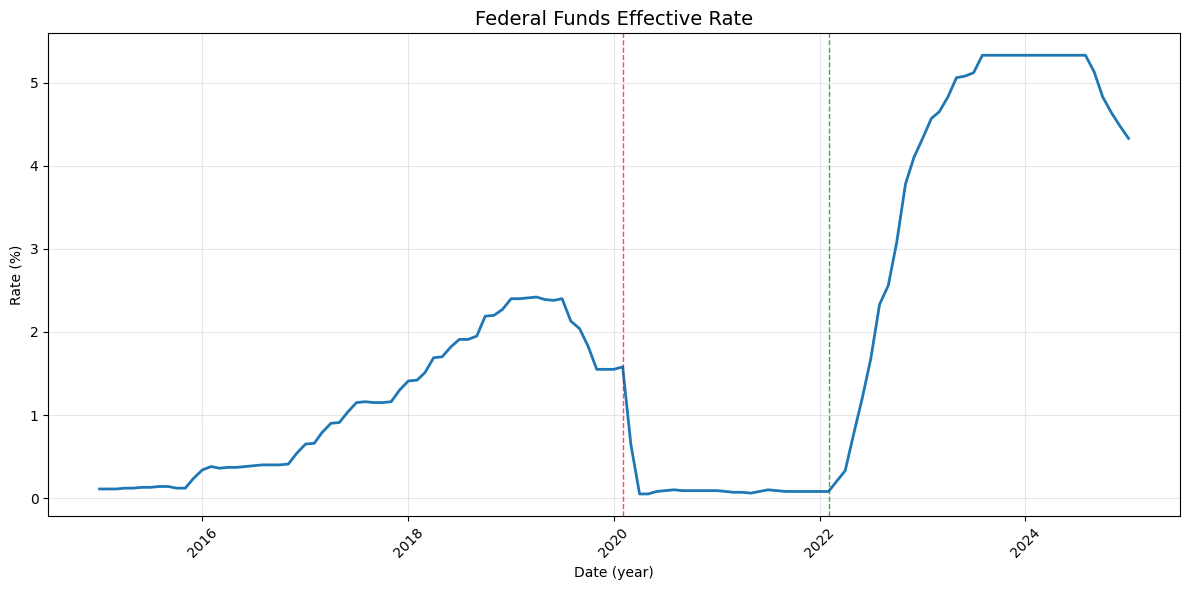

In [21]:
f = pd.read_csv('FEDFUNDS.csv')

df = pd.DataFrame(f)
pd.set_option('display.max_rows', None)
print(df.head())
df['observation_date'] = pd.to_datetime(df['observation_date'])

plt.figure(figsize=(12, 6))
plt.plot(df['observation_date'], df['FEDFUNDS'], linewidth=2)
plt.title('Federal Funds Effective Rate', fontsize=14)
plt.axvline(x=pd.Timestamp('2020-02-01'), color='red', linestyle='--', linewidth=1, alpha=0.7)
plt.axvline(x=pd.Timestamp('2022-02-01'), color='green', linestyle='--', linewidth=1, alpha=0.7)
plt.xlabel('Date (year)')
plt.ylabel('Rate (%)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                 Date Ticker        Bank_Name      Open      High       Low  \
0 1973-02-21 05:00:00    BAC  Bank of America  1.507640  1.507640  1.507640   
1 1973-02-22 05:00:00    BAC  Bank of America  1.512733  1.512733  1.512733   
2 1973-02-23 05:00:00    BAC  Bank of America  1.507640  1.507640  1.507640   
3 1973-02-26 05:00:00    BAC  Bank of America  1.507640  1.507640  1.507640   
4 1973-02-27 05:00:00    BAC  Bank of America  1.507640  1.507640  1.507640   

      Close  Volume  Dividends  Stock Splits  
0  1.507640   99200        0.0           0.0  
1  1.512733   47200        0.0           0.0  
2  1.507640  133600        0.0           0.0  
3  1.507640   24000        0.0           0.0  
4  1.507640   41600        0.0           0.0  


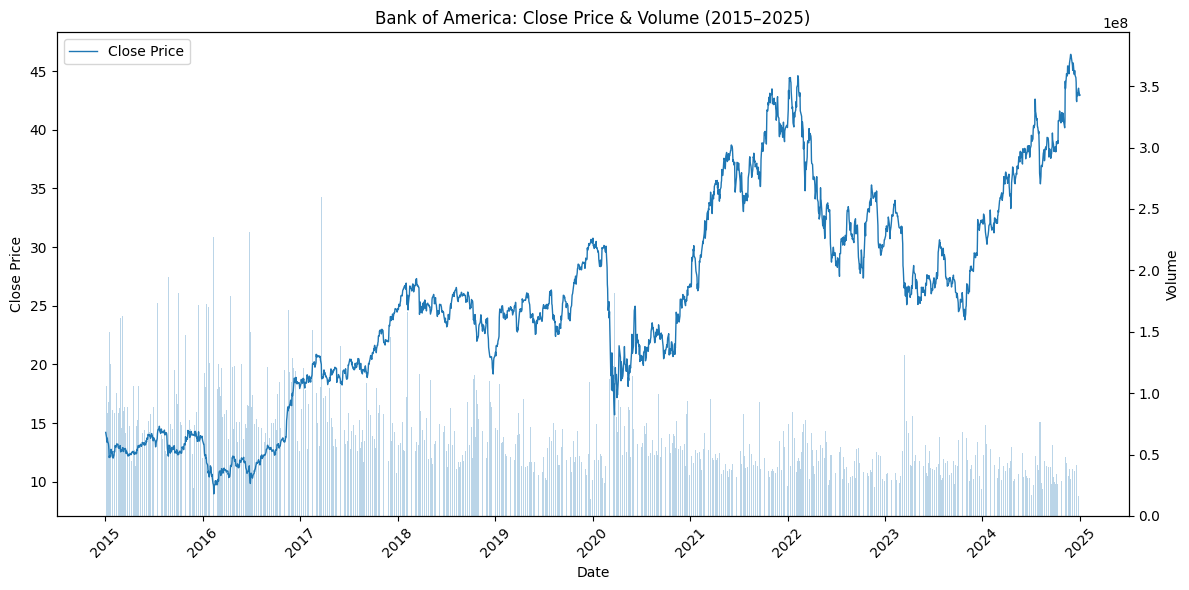

In [22]:
b1 = pd.read_csv('BAC_Bank_of_America.csv')

b1['Date'] = pd.to_datetime(b1['Date'], utc=True).dt.tz_convert(None)

filtered = b1[
    (b1['Date'] >= '2015-01-01') &
    (b1['Date'] <= '2025-01-01')
]

result = filtered[['Date', 'Bank_Name', 'Close', 'Volume']]

print(b1.head())

result.to_csv('BAC_selected_columns_2015_2025.csv', index=False)
result = result.sort_values('Date')

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(result['Date'], result['Close'], label='Close Price', linewidth=1)
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.bar(result['Date'], result['Volume'], alpha=0.3)
ax2.set_ylabel('Volume')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.title('Bank of America: Close Price & Volume (2015–2025)')
plt.tight_layout()
plt.show()


Close vs FEDFUNDS: r=0.4421, p=0.0000
Volume vs FEDFUNDS: r=-0.5044, p=0.0000


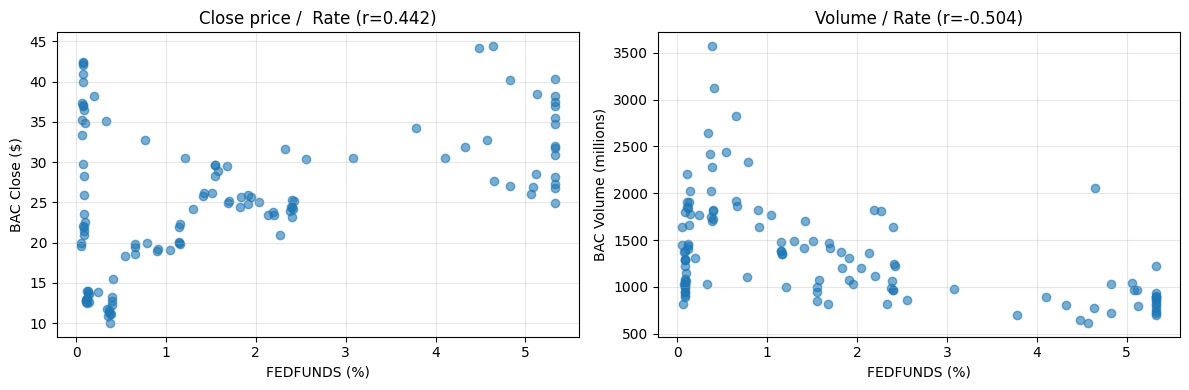

Close vs FEDFUNDS: r=0.8744, p=0.0000
Volume vs FEDFUNDS: r=-0.6212, p=0.0000


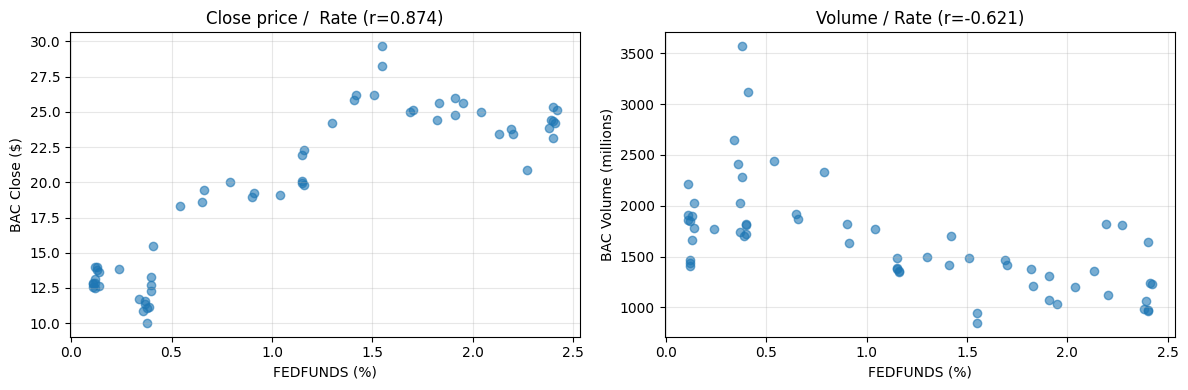

In [24]:

bac = pd.read_csv('BAC_Bank_of_America.csv')
fed = pd.read_csv('FEDFUNDS.csv')

bac['Date'] = pd.to_datetime(bac['Date'], utc=True).dt.tz_convert(None)
fed['observation_date'] = pd.to_datetime(fed['observation_date'])

bac_filtered = bac[(bac['Date'] >= '2015-01-01') & (bac['Date'] <= '2025-01-01')].copy()

bac_filtered['YearMonth'] = bac_filtered['Date'].dt.to_period('M')
fed['YearMonth'] = fed['observation_date'].dt.to_period('M')

monthly_bac = bac_filtered.groupby('YearMonth').agg({
    'Close': 'mean',
    'Volume': 'sum'
}).reset_index()

monthly_data = pd.merge(monthly_bac, fed[['YearMonth', 'FEDFUNDS']], on='YearMonth', how='inner')

corr_close, p_close = stats.pearsonr(monthly_data['Close'], monthly_data['FEDFUNDS'])
corr_volume, p_volume = stats.pearsonr(monthly_data['Volume'], monthly_data['FEDFUNDS'])

print(f"Close vs FEDFUNDS: r={corr_close:.4f}, p={p_close:.4f}")
print(f"Volume vs FEDFUNDS: r={corr_volume:.4f}, p={p_volume:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(monthly_data['FEDFUNDS'], monthly_data['Close'], alpha=0.6)
plt.xlabel('FEDFUNDS (%)')
plt.ylabel('BAC Close ($)')
plt.title(f'Close price /  Rate (r={corr_close:.3f})')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(monthly_data['FEDFUNDS'], monthly_data['Volume']/1e6, alpha=0.6)
plt.xlabel('FEDFUNDS (%)')
plt.ylabel('BAC Volume (millions)')
plt.title(f'Volume / Rate (r={corr_volume:.3f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

monthly_data.to_csv('bac_fed_correlation.csv', index=False)


bac['Date'] = pd.to_datetime(bac['Date'], utc=True).dt.tz_convert(None)
fed['observation_date'] = pd.to_datetime(fed['observation_date'])

bac_filtered = bac[(bac['Date'] >= '2015-01-01') & (bac['Date'] <= '2020-01-01')].copy()

bac_filtered['YearMonth'] = bac_filtered['Date'].dt.to_period('M')
fed['YearMonth'] = fed['observation_date'].dt.to_period('M')

monthly_bac = bac_filtered.groupby('YearMonth').agg({
    'Close': 'mean',
    'Volume': 'sum'
}).reset_index()

monthly_data = pd.merge(monthly_bac, fed[['YearMonth', 'FEDFUNDS']], on='YearMonth', how='inner')

corr_close, p_close = stats.pearsonr(monthly_data['Close'], monthly_data['FEDFUNDS'])
corr_volume, p_volume = stats.pearsonr(monthly_data['Volume'], monthly_data['FEDFUNDS'])

print(f"Close vs FEDFUNDS: r={corr_close:.4f}, p={p_close:.4f}")
print(f"Volume vs FEDFUNDS: r={corr_volume:.4f}, p={p_volume:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(monthly_data['FEDFUNDS'], monthly_data['Close'], alpha=0.6)
plt.xlabel('FEDFUNDS (%)')
plt.ylabel('BAC Close ($)')
plt.title(f'Close price /  Rate (r={corr_close:.3f})')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(monthly_data['FEDFUNDS'], monthly_data['Volume']/1e6, alpha=0.6)
plt.xlabel('FEDFUNDS (%)')
plt.ylabel('BAC Volume (millions)')
plt.title(f'Volume / Rate (r={corr_volume:.3f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

monthly_data.to_csv('bac_fed_correlation.csv', index=False)

Close vs Volume: r=-0.5559, p=0.0000


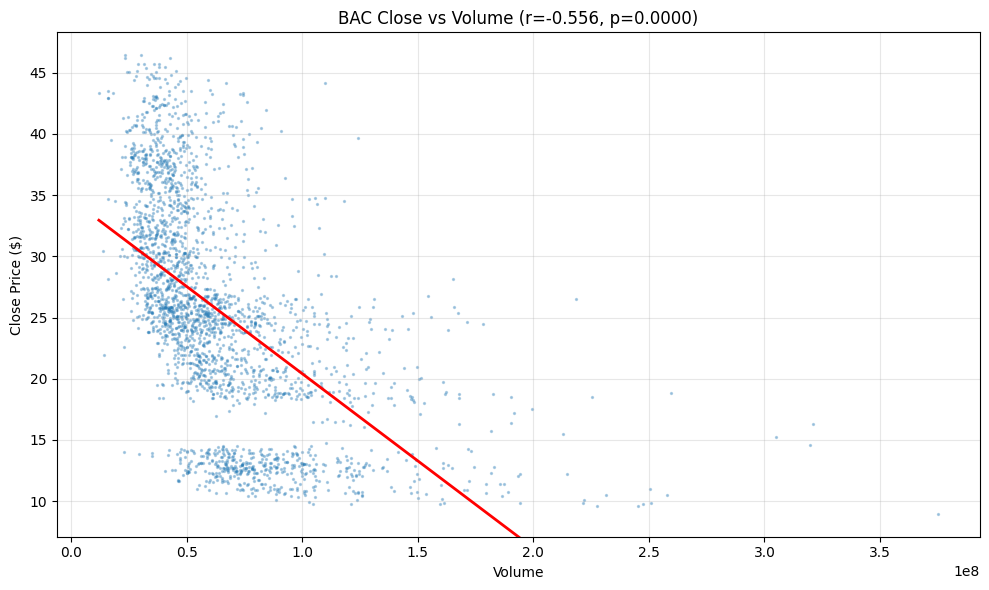

In [25]:
bac['Date'] = pd.to_datetime(bac['Date'], utc=True).dt.tz_convert(None)
bac_filtered = bac[(bac['Date'] >= '2015-01-01') & (bac['Date'] <= '2025-01-01')].copy()

corr_close_volume, p_close_volume = stats.pearsonr(bac_filtered['Close'], bac_filtered['Volume'])

print(f"Close vs Volume: r={corr_close_volume:.4f}, p={p_close_volume:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(bac_filtered['Volume'], bac_filtered['Close'], alpha=0.3, s=2)

y_min, y_max = plt.ylim()

z = np.polyfit(bac_filtered['Volume'], bac_filtered['Close'], 1)
p = np.poly1d(z)
plt.plot(sorted(bac_filtered['Volume']), p(sorted(bac_filtered['Volume'])),
         "r-", linewidth=2, label=f'Trend line (slope={z[0]:.2e})')


plt.ylim(y_min, y_max)

plt.xlabel('Volume')
plt.ylabel('Close Price ($)')
plt.title(f'BAC Close vs Volume (r={corr_close_volume:.3f}, p={p_close_volume:.4f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()